In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [31]:
df = pd.read_csv("shoes.csv")
df

,Sale_ID,Date,Brand,Shoe_Type,Color,Country,Sales_Channel,Price_USD,Units_Sold,Revenue_USD
0,S1,24-11-2025,Nike,Boots,Blue,UK,Online,112.40,4,449.60
1,S2,13-03-2025,Skechers,Boots,Grey,USA,Mall,239.16,4,956.64
2,S3,05-08-2025,Nike,Running,White,UK,Mall,191.04,2,382.08
3,S4,05-11-2025,New Balance,Casual,Green,UAE,Mall,161.70,1,161.70
4,S5,07-10-2025,Adidas,Formal,Grey,France,Online,64.32,14,900.48
...,...,...,...,...,...,...,...,...,...,...
995,S996,06-06-2025,Puma,Sneakers,Red,India,Online,50.15,6,300.90
996,S997,14-08-2025,Adidas,Casual,Green,France,Online,231.81,2,463.62
997,S998,13-02-2025,Skechers,Running,White,India,Online,60.10,4,240.40
998,S999,28-05-2025,Puma,Boots,Black,France,Retail Store,239.05,1,239.05


In [32]:
print("First 5 rows:")
print(df.head())

First 5 rows:
  Sale_ID        Date        Brand Shoe_Type  Color Country Sales_Channel  \
0      S1  24-11-2025         Nike     Boots   Blue      UK        Online   
1      S2  13-03-2025     Skechers     Boots   Grey     USA          Mall   
2      S3  05-08-2025         Nike   Running  White      UK          Mall   
3      S4  05-11-2025  New Balance    Casual  Green     UAE          Mall   
4      S5  07-10-2025       Adidas    Formal   Grey  France        Online   

   Price_USD  Units_Sold  Revenue_USD  
0     112.40           4       449.60  
1     239.16           4       956.64  
2     191.04           2       382.08  
3     161.70           1       161.70  
4      64.32          14       900.48  


In [33]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sale_ID        1000 non-null   str    
 1   Date           1000 non-null   str    
 2   Brand          1000 non-null   str    
 3   Shoe_Type      1000 non-null   str    
 4   Color          1000 non-null   str    
 5   Country        1000 non-null   str    
 6   Sales_Channel  1000 non-null   str    
 7   Price_USD      1000 non-null   float64
 8   Units_Sold     1000 non-null   int64  
 9   Revenue_USD    1000 non-null   float64
dtypes: float64(2), int64(1), str(7)
memory usage: 78.3 KB
None


In [34]:
print(df.isnull().sum())


Sale_ID          0
Date             0
Brand            0
Shoe_Type        0
Color            0
Country          0
Sales_Channel    0
Price_USD        0
Units_Sold       0
Revenue_USD      0
dtype: int64


In [35]:
df = df.drop_duplicates()

In [36]:
df.describe()

,Price_USD,Units_Sold,Revenue_USD
count,1000.000000,1000.000000,1000.00000
mean,137.856420,10.584000,1453.18603
std,64.270059,5.842181,1112.32648
min,31.020000,1.000000,32.38000
25%,81.915000,6.000000,561.05000
50%,139.295000,10.000000,1132.62500
75%,193.752500,16.000000,2163.35000
max,249.940000,20.000000,4938.40000


In [37]:
df.drop_duplicates(inplace=True)

In [38]:
df['Price_USD'].describe()

count    1000.000000
mean      137.856420
std        64.270059
min        31.020000
25%        81.915000
50%       139.295000
75%       193.752500
max       249.940000
Name: Price_USD, dtype: float64

<Axes: xlabel='Price_USD', ylabel='Count'>

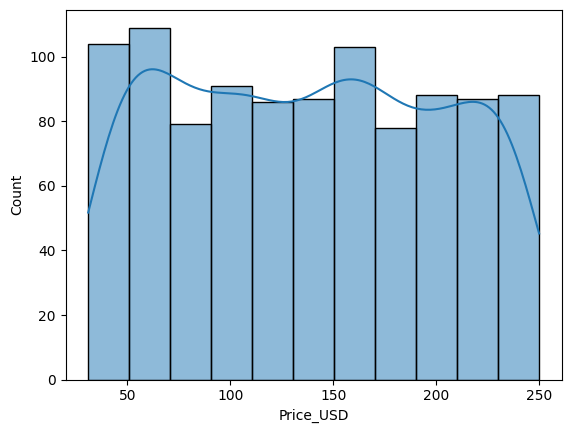

In [39]:
sns.histplot(df['Price_USD'], kde=True)

<Axes: xlabel='Price_USD'>

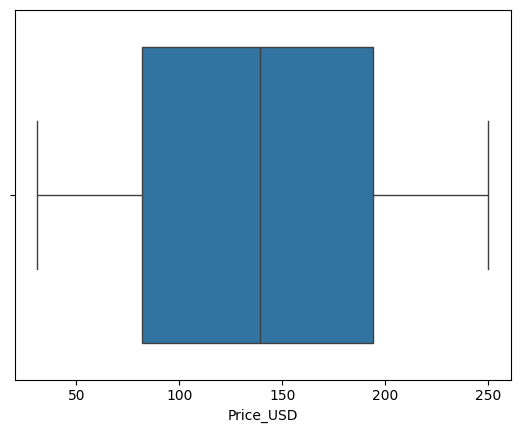

In [40]:
sns.boxplot(x=df['Price_USD'])


<Axes: xlabel='Units_Sold', ylabel='Count'>

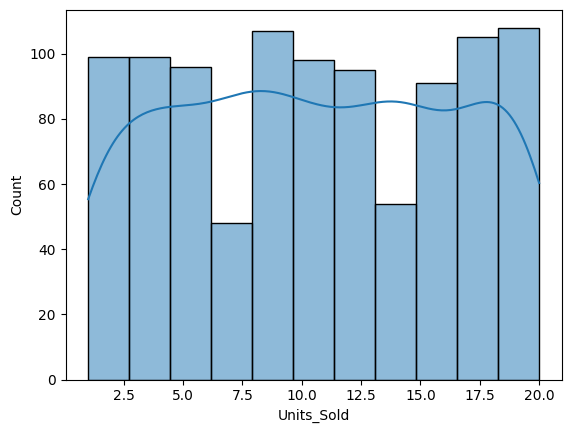

In [41]:
sns.histplot(df['Units_Sold'], kde=True)

In [42]:
df['Date'] = pd.to_datetime(df['Date'])


C:\Users\ankit\AppData\Local\Temp\ipykernel_16912\3386729631.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


<Axes: xlabel='Revenue_USD', ylabel='Count'>

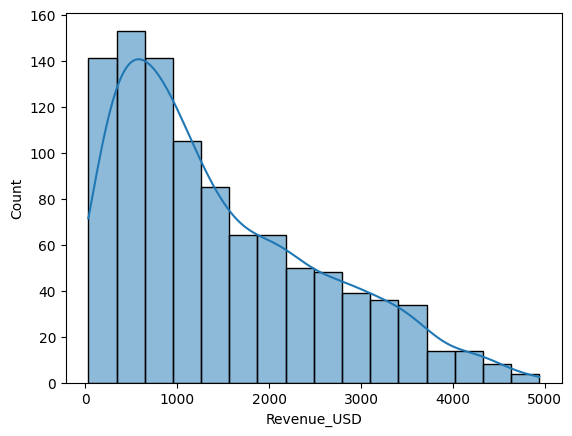

In [43]:
sns.histplot(df['Revenue_USD'], kde=True)

<Axes: xlabel='Price_USD', ylabel='Units_Sold'>

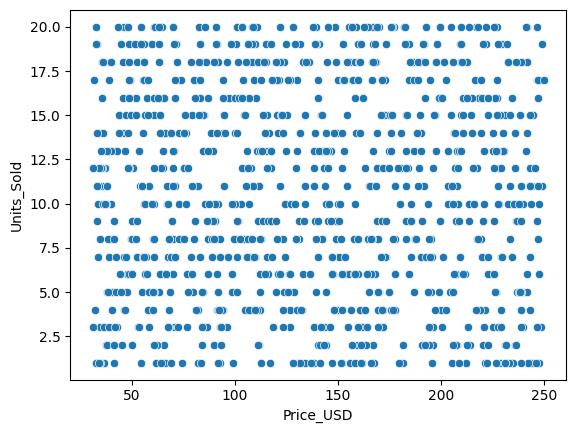

In [45]:
sns.scatterplot(data=df, x='Price_USD', y='Units_Sold')


<Axes: xlabel='Price_USD', ylabel='Revenue_USD'>

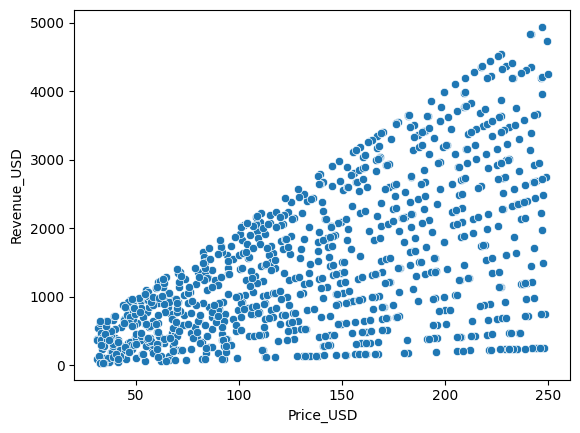

In [46]:
sns.scatterplot(data=df, x='Price_USD', y='Revenue_USD')

<Axes: xlabel='Brand', ylabel='Revenue_USD'>

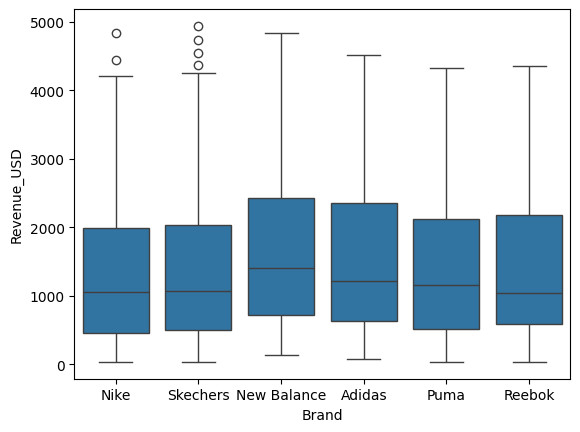

In [47]:
sns.boxplot(data=df, x='Brand', y='Revenue_USD')


<Axes: xlabel='Sales_Channel', ylabel='Units_Sold'>

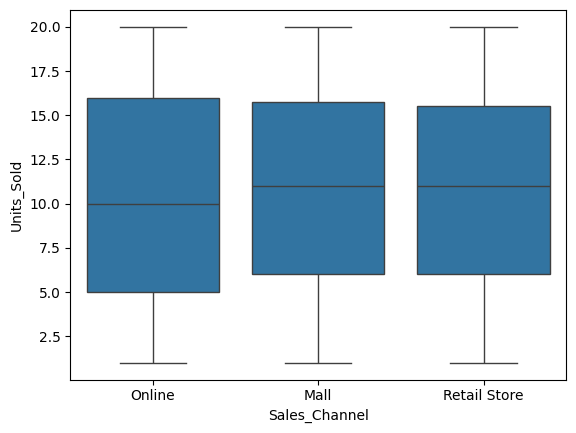

In [48]:
sns.boxplot(data=df, x='Sales_Channel', y='Units_Sold')


<Axes: xlabel='Date'>

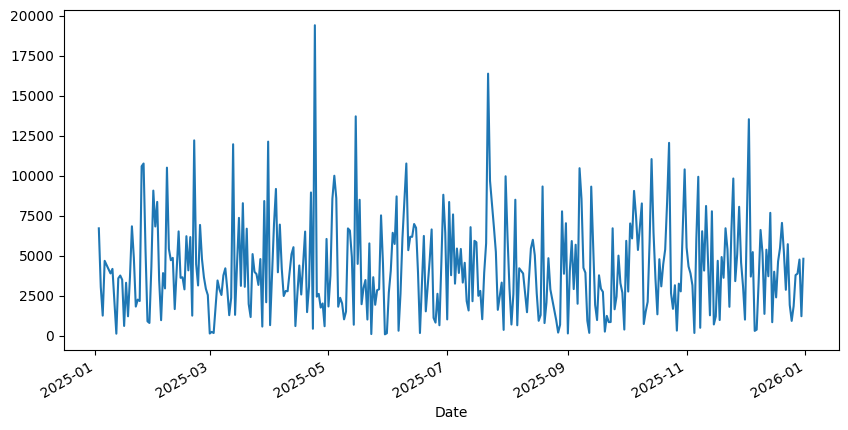

In [49]:
df.groupby('Date')['Revenue_USD'].sum().plot(figsize=(10,5))


<Axes: >

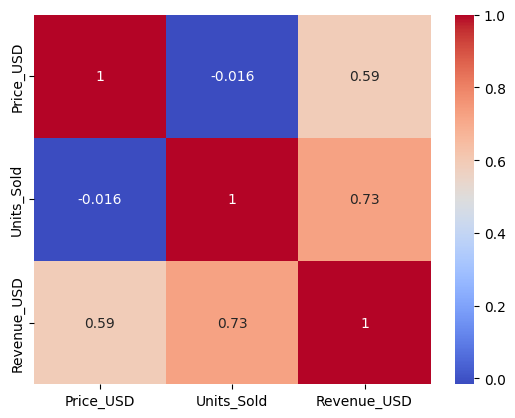

In [51]:
sns.heatmap(df[['Price_USD','Units_Sold','Revenue_USD']].corr(),
            annot=True, cmap='coolwarm')


<Axes: xlabel='Brand'>

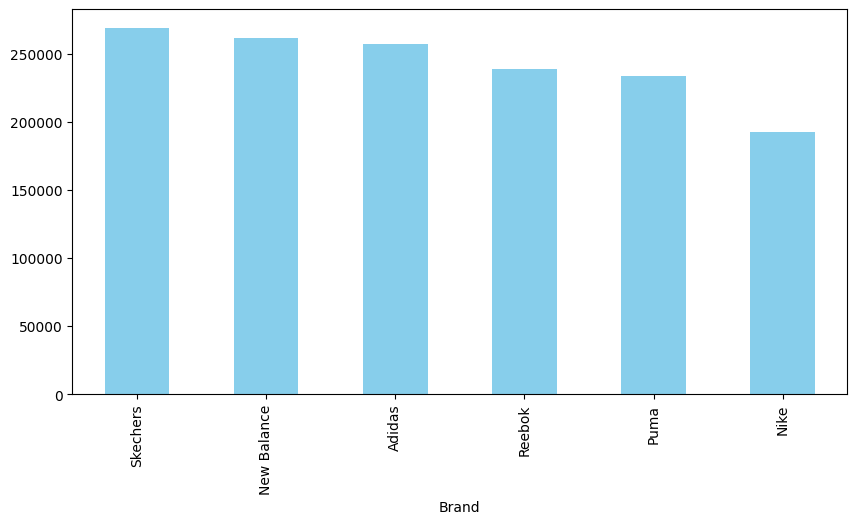

In [52]:
top_brands = df.groupby('Brand')['Revenue_USD'].sum().sort_values(ascending=False)

top_brands.plot(kind='bar', figsize=(10,5), color='skyblue')

Text(0.5, 1.0, 'Revenue by Country')

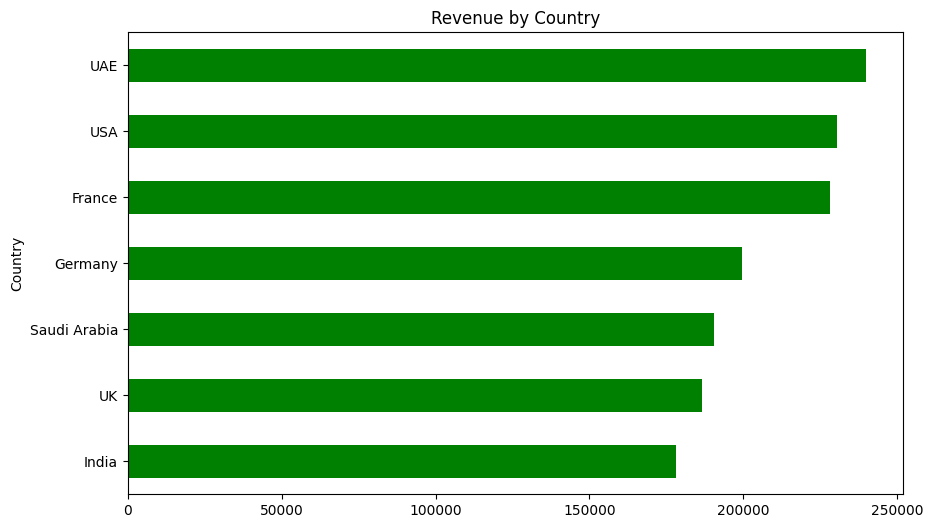

In [58]:
country_sales = df.groupby('Country')['Revenue_USD'].sum().sort_values()

country_sales.plot(kind='barh', figsize=(10,6), color='green')
plt.title("Revenue by Country")

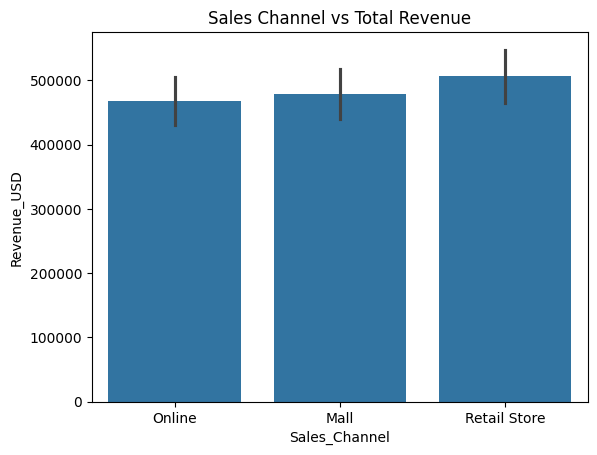

In [59]:
sns.barplot(data=df, x='Sales_Channel', y='Revenue_USD', estimator=sum)
plt.title("Sales Channel vs Total Revenue")
plt.show()

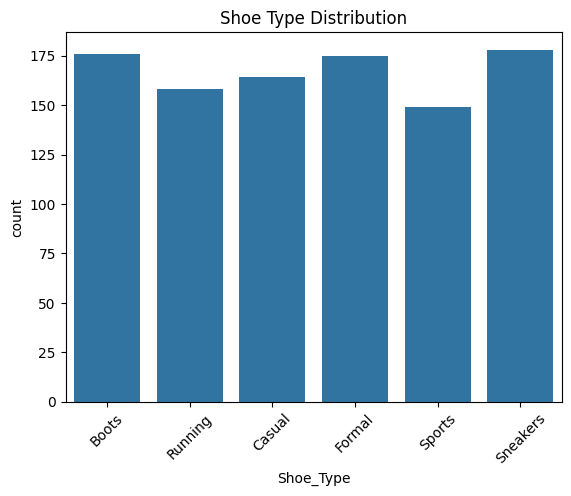

In [60]:
sns.countplot(data=df, x='Shoe_Type')
plt.xticks(rotation=45)
plt.title("Shoe Type Distribution")
plt.show()

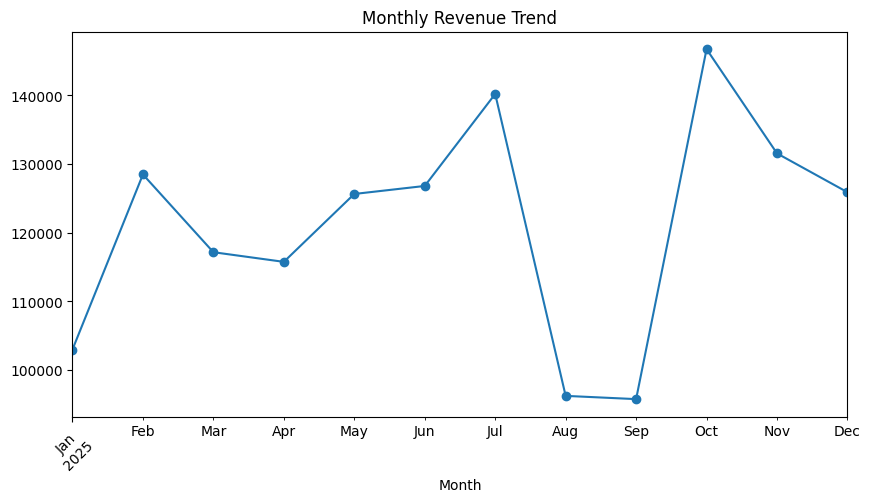

In [61]:
df['Month'] = df['Date'].dt.to_period('M')

monthly = df.groupby('Month')['Revenue_USD'].sum()

monthly.plot(figsize=(10,5), marker='o')
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.show()

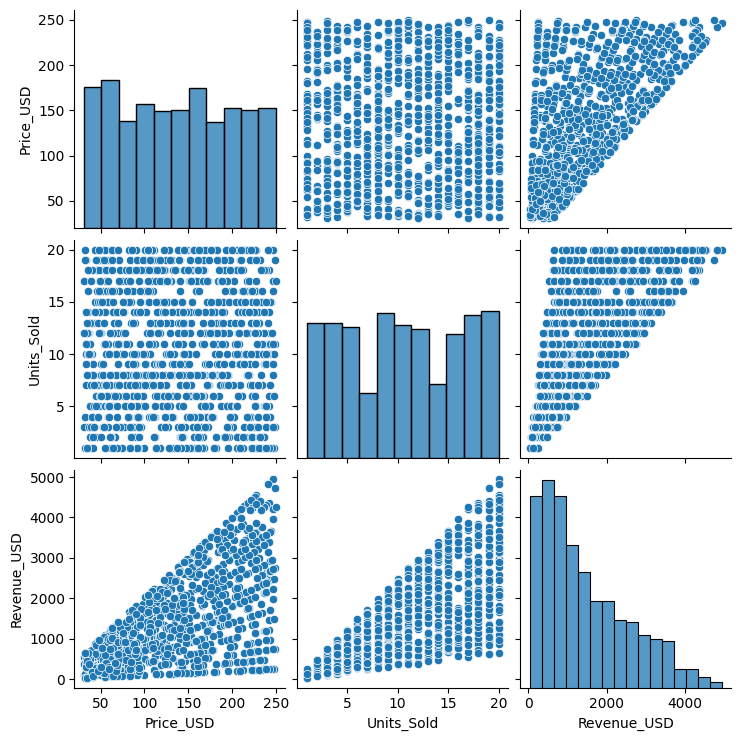

In [62]:
sns.pairplot(df[['Price_USD','Units_Sold','Revenue_USD']])
plt.show()

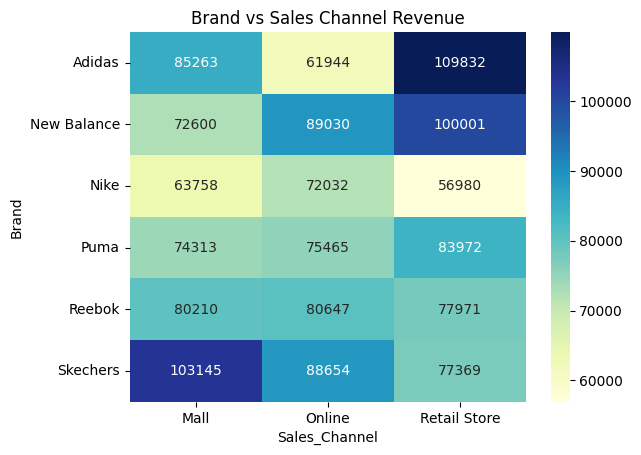

In [63]:
pivot = df.pivot_table(values='Revenue_USD',
                       index='Brand',
                       columns='Sales_Channel',
                       aggfunc='sum')

sns.heatmap(pivot, annot=True, fmt=".0f", cmap='YlGnBu')
plt.title("Brand vs Sales Channel Revenue")
plt.show()

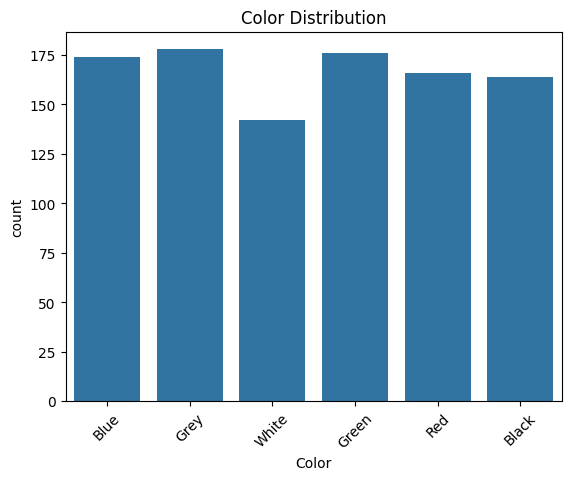

In [64]:
sns.countplot(data=df, x='Color')
plt.xticks(rotation=45)
plt.title("Color Distribution")
plt.show()

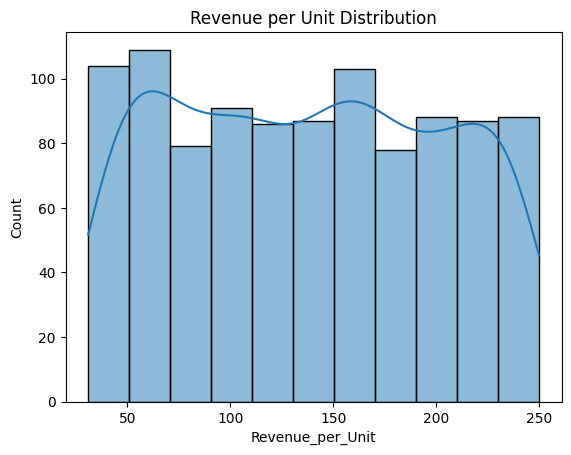

In [65]:
df['Revenue_per_Unit'] = df['Revenue_USD'] / df['Units_Sold']

sns.histplot(df['Revenue_per_Unit'], kde=True)
plt.title("Revenue per Unit Distribution")
plt.show()

In [66]:
top_sales = df.sort_values(by='Revenue_USD', ascending=False).head(10)
print(top_sales)

    Sale_ID       Date        Brand Shoe_Type  Color       Country  \
446    S447 2025-01-31     Skechers     Boots   Grey       Germany   
140    S141 2025-11-07  New Balance    Casual   Grey       Germany   
843    S844 2025-11-11         Nike  Sneakers   Grey  Saudi Arabia   
847    S848 2025-06-29     Skechers     Boots   Grey           USA   
191    S192 2025-01-26     Skechers    Formal   Blue  Saudi Arabia   
280    S281 2025-04-03       Adidas     Boots    Red           USA   
795    S796 2025-06-04         Nike    Sports    Red       Germany   
825    S826 2025-05-15  New Balance  Sneakers  White       Germany   
336    S337 2025-06-05  New Balance   Running   Grey           UAE   
104    S105 2025-10-31     Skechers   Running  Black           UAE   

    Sales_Channel  Price_USD  Units_Sold  Revenue_USD    Month  \
446          Mall     246.92          20      4938.40  2025-01   
140  Retail Store     241.74          20      4834.80  2025-11   
843        Online     241.44   